In [3]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from physics_utils import *

Failed to reload module 'packaging._structures' from file 'c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.venv\Lib\site-packages\packaging\_structures.py'
Traceback (most recent call last):
  File "c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 625, in superreload
    update_generic(old_obj, new_obj)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 451, in update_generic
    update(a, b)
    ~~~~~~^^^^^^
  File "c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 419, in update_class
    upd

[autoreload of packaging._structures failed: Traceback (most recent call last):
  File "c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 625, in superreload
    update_generic(old_obj, new_obj)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 451, in update_generic
    update(a, b)
    ~~~~~~^^^^^^
  File "c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 419, in update_class
    update_instances(old, new)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "c:\Projects\PV Cells Fault CV\Deep-Photonics-Reliability\.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
df = pd.read_csv('../data/fixed_labels.csv') 

# since we have 4 props we will get one image from each propability 
samples = {prob: df[df['prop'] == prob].iloc[0]['path'] for prob in [0.0, 0.33, 0.67, 1.0]}

In [5]:
samples

{0.0: 'images/cell0004.png',
 0.33: 'images/cell0058.png',
 0.67: 'images/cell0070.png',
 1.0: 'images/cell0001.png'}

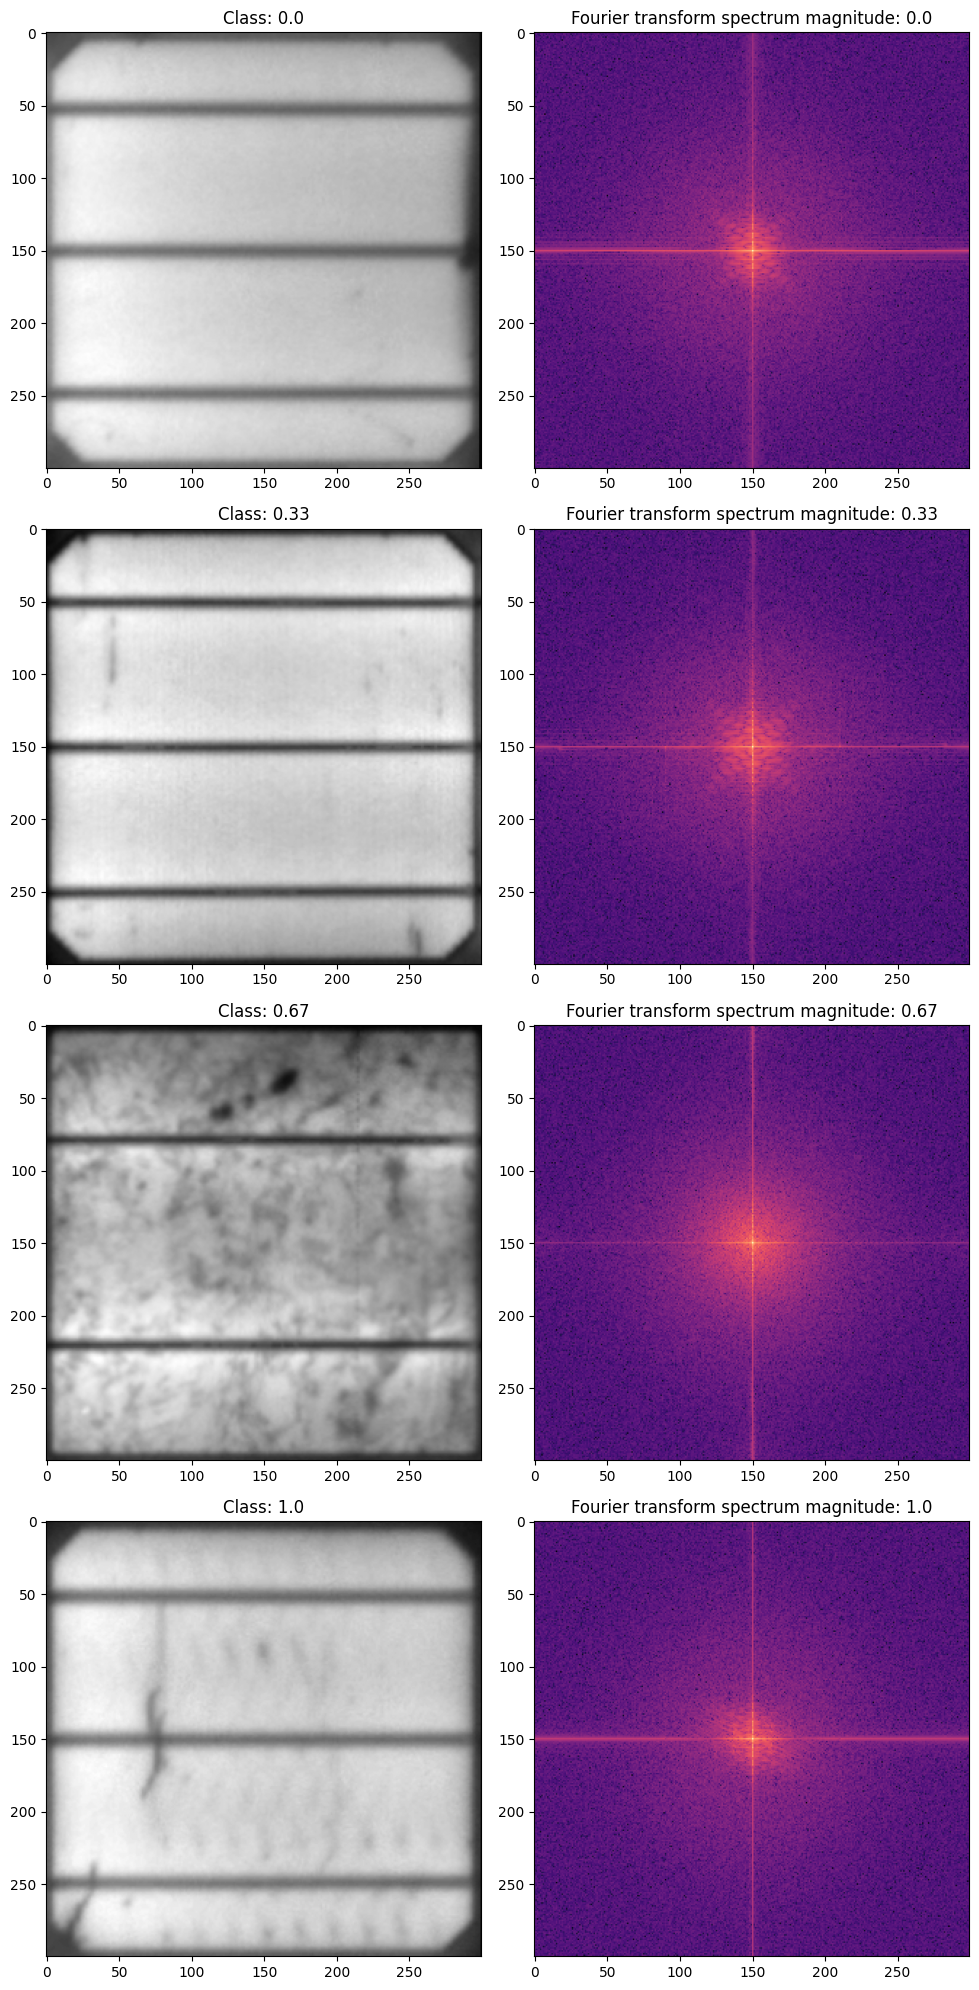

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
for i, (prob, path) in enumerate(samples.items()):
    img = cv2.imread(f"../data/{path}", 0) 
    shift, spectrum = compute_fft_spectrum(img)
    
    axes[i,0].imshow(img, cmap='gray')
    axes[i,0].set_title(f"Class: {prob}")
    axes[i,1].imshow(spectrum, cmap='magma')
    axes[i,1].set_title(f"Fourier transform spectrum magnitude: {prob}")
plt.tight_layout()
plt.show()

**lets test or smoothing guassian filter now**

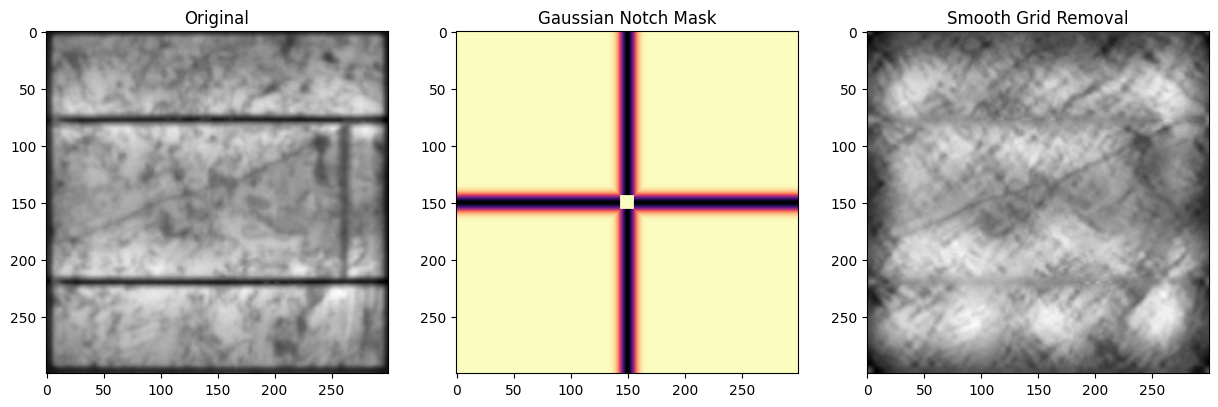

In [7]:
img = cv2.imread(f'../data/images/cell0076.png', 0) # this is a poly cell with label of 1.0 since this is the most important case to smooth out
dft_shift, spectrum = compute_fft_spectrum(img)
filtered_dft, mask = apply_gaussian_notch_filter(dft_shift)
cleaned_img = reconstruct_image(filtered_dft,apply_bilateral=False)

# plot the sample
plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title("Original")
plt.subplot(132), plt.imshow(mask, cmap='magma'), plt.title("Gaussian Notch Mask")
plt.subplot(133), plt.imshow(cleaned_img, cmap='gray'), plt.title("Smooth Grid Removal")
plt.show()